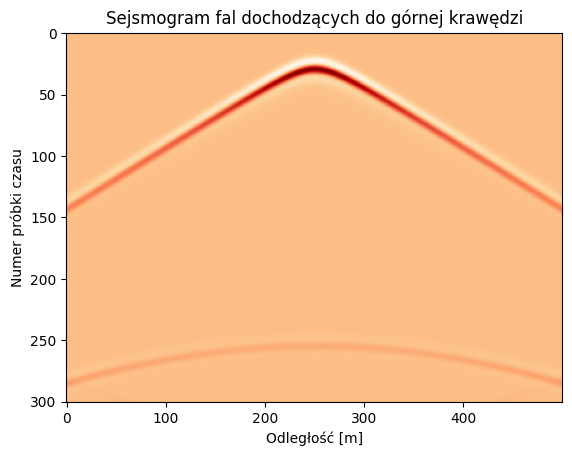

In [18]:
import numpy as np
import math
import matplotlib.pyplot as plt

nz = 500
nx = 500
fpeak = 30.0
dt = 0.002
et = 0.6
ds = 1.0

vmax = 2000.0
dtr = 0.00025

#wariant wektorowy
dtr_ds = dtr / ds

p = np.zeros((nz, nx))
pm = np.zeros((nz, nx))
pp = np.zeros((nz, nx))
V = np.zeros((nz, nx))

V[:250, :] = 1000.0
V[250:, :] = 2000.0

src_z = 25
src_x = 250

nrec = int(et / dt) + 1
sejsmogram = np.zeros((nrec, nx))

k = 0
kk = 0
kkk = 0

while True:
    k = k + 1
    kk = kk + 1
    t = k * dtr

    # przeliczenie "po sasiedzku"
    pp[1:-1, 1:-1] = 2.0 * p[1:-1, 1:-1] - pm[1:-1, 1:-1] + ((dtr * dtr) / (ds * ds)) * V[1:-1, 1:-1] * V[1:-1, 1:-1] * (p[2:, 1:-1] + p[:-2, 1:-1] + p[1:-1, 2:] + p[1:-1, :-2] - 4.0 * p[1:-1, 1:-1])

    # dodanie Rickera
    s = math.exp(-((math.pi*fpeak*(t-(1.0/fpeak))) * (math.pi*fpeak*(t-(1.0/fpeak))))) * (1.0 - 2.0 * ((math.pi*fpeak*(t-(1.0/fpeak))) * (math.pi*fpeak*(t-(1.0/fpeak)))))
    pp[25, 250] = pp[25, 250] + s

    # Lewa granica
    pp[:, 0] = p[:, 0] + p[:, 1] - pm[:, 1] + V[:, 0] * dtr_ds * (p[:, 1] - p[:, 0] - (pm[:, 2] - pm[:, 1]))

    pp[:, -1] = p[:, -1] + p[:, -2] - pm[:, -2] + V[:, -1] * dtr_ds * (p[:, -2] - p[:, -1] - (pm[:, -3] - pm[:, -2]))
    pp[0, :] = p[0, :] + p[1, :] - pm[1, :] + V[0, :] * dtr_ds * (p[1, :] - p[0, :] - (pm[2, :] - pm[1, :]))
    pp[-1, :] = p[-1, :] + p[-2, :] - pm[-2, :] + V[-1, :] * dtr_ds * (p[-2, :] - p[-1, :] - (pm[-3, :] - pm[-2, :]))

    # krok do przodu
    pm[:] = p[:]
    p[:] = pp[:]

    if kk*dtr + dtr/10.0 >= dt:
        kk = 0
        sejsmogram[kkk, :] = p[0, :]
        kkk = kkk + 1
        #print(kkk*dt, "\r")
        if kkk * dt > et:
            break

plt.imshow(sejsmogram, aspect='auto', cmap='OrRd')
plt.xlabel('Odległość [m]')
plt.ylabel('Numer próbki czasu')
plt.title('Sejsmogram fal dochodzących do górnej krawędzi')
plt.show()

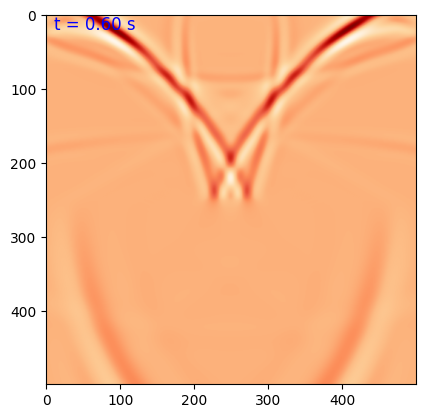

In [25]:
nz = 500
nx = 500
fpeak = 30.0
dt = 0.002
et = 0.6
ds = 1.0

vmax = 2000.0
dtr = 0.00025

#wariant wektorowy
dtr_ds = dtr / ds

p = np.zeros((nz, nx))
pm = np.zeros((nz, nx))
pp = np.zeros((nz, nx))
V = np.zeros((nz, nx))

V[:250, :] = 1000.0
V[250:, :] = 2000.0

src_z = 25
src_x = 250

nrec = int(et / dt) + 1
sejsmogram = np.zeros((nrec, nx))

k = 0
kk = 0
kkk = 0

fig, ax = plt.subplots()
ims = []

while True:
    k = k + 1
    kk = kk + 1
    t = k * dtr

    # przeliczenie "po sasiedzku"
    pp[1:-1, 1:-1] = 2.0 * p[1:-1, 1:-1] - pm[1:-1, 1:-1] + ((dtr * dtr) / (ds * ds)) * V[1:-1, 1:-1] * V[1:-1, 1:-1] * (p[2:, 1:-1] + p[:-2, 1:-1] + p[1:-1, 2:] + p[1:-1, :-2] - 4.0 * p[1:-1, 1:-1])

    # dodanie Rickera
    s = math.exp(-((math.pi*fpeak*(t-(1.0/fpeak))) * (math.pi*fpeak*(t-(1.0/fpeak))))) * (1.0 - 2.0 * ((math.pi*fpeak*(t-(1.0/fpeak))) * (math.pi*fpeak*(t-(1.0/fpeak)))))
    pp[25, 250] = pp[25, 250] + s

    # Lewa granica
    pp[:, 0] = p[:, 0] + p[:, 1] - pm[:, 1] + V[:, 0] * dtr_ds * (p[:, 1] - p[:, 0] - (pm[:, 2] - pm[:, 1]))

    pp[:, -1] = p[:, -1] + p[:, -2] - pm[:, -2] + V[:, -1] * dtr_ds * (p[:, -2] - p[:, -1] - (pm[:, -3] - pm[:, -2]))
    pp[0, :] = p[0, :] + p[1, :] - pm[1, :] + V[0, :] * dtr_ds * (p[1, :] - p[0, :] - (pm[2, :] - pm[1, :]))
    pp[-1, :] = p[-1, :] + p[-2, :] - pm[-2, :] + V[-1, :] * dtr_ds * (p[-2, :] - p[-1, :] - (pm[-3, :] - pm[-2, :]))

    # krok do przodu
    pm[:] = p[:]
    p[:] = pp[:]

    if kk*dtr + dtr/100.0 >= dt:
        img = ax.imshow(p, cmap='OrRd', animated=True)
        txt = ax.text(10, 20, f"t = {t:.2f} s", color='blue', fontsize=12, animated=True)
        ims.append([img, txt])

        kk = 0
        sejsmogram[kkk, :] = p[0, :]
        kkk = kkk + 1
        #print(kkk*dt, "\r")
        if kkk * dt > et:
            break

ani = animation.ArtistAnimation(fig, ims, interval=150, blit=True, repeat = False)
from IPython.display import HTML
HTML(ani.to_html5_video())